# Electric drives, part 1: modelling an interior PMSM you can differentiate

A permanent-magnet synchronous motor (PMSM) is the workhorse of modern motion —
EV traction, robot joints, drones, industrial servos. Getting torque, losses
and thermal limits right is the whole game, and almost every controller in the
field (field-oriented control) is built on one compact model: the **rotor
reference-frame (dq) machine**. This series builds that model from first
principles in Jaxonomy, closes a field-oriented control loop around it, couples
it to a thermal network that derates torque as the windings heat, calibrates it
against bench data, quantifies design margins under uncertainty, and finally
lowers the current loop to embedded C for an Arm Cortex-M target.

Because the whole machine is a differentiable Jaxonomy block, the same model
serves simulation, gradient-based tuning, sensitivity analysis and code
generation — *one model, one truth*.

**By the end of this notebook you will be able to:**
1. Write the dq voltage, torque and mechanical equations for an interior PMSM
   (with magnetic saliency $L_d \neq L_q$).
2. Author the machine as a self-contained `LeafSystem` and simulate it.
3. Validate it against analytic ground truth — electrical time constants, the
   torque/saliency relation, and an instantaneous power balance.
4. Read an open-loop spin-up and explain every feature of the trace.

*Reading time ~25 min · runtime ~1 min on CPU.*

> **The arc (six parts).**
> **1 — Modelling (this notebook):** dq machine + averaged inverter, validated.
> **2 — Field-oriented control:** Clarke/Park, cascaded dq current PI, speed loop.
> **3 — Thermal & derating:** couple $I^2R$ losses to an acausal thermal network; torque derates with winding temperature; multi-rate simulation.
> **4 — Calibration:** recover machine parameters from bench data by forward-mode system identification.
> **5 — Design margins:** Sobol sensitivity + Monte-Carlo over parameter uncertainty; VaR/CVaR on peak temperature and torque shortfall.
> **6 — Deployment:** lower the current loop to acados and cross-compile for Cortex-M, with an attestation manifest.

> **Out of scope, on purpose.** Hard PWM switching harmonics (we use an
> *averaged* inverter — Part 2 keeps it averaged; switching ripple is a separate
> study), iron/eddy losses beyond a lumped term (folded into the thermal source
> in Part 3), and magnetic saturation $L_d(i_d), L_q(i_q)$ (constant inductances
> here; a lookup-table extension is noted in the exercises).


## Prerequisites

This notebook is self-contained. Familiarity helps:
- [Creating custom blocks](../tutorials/02-creating-custom-blocks.ipynb) — the `LeafSystem` API.
- [Automatic differentiation & optimization](../tutorials/05-automatic-differentiation-optimization.ipynb) — used heavily from Part 2 on.

No special installs beyond Jaxonomy.

In [1]:
# Standard scientific Python
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# JAX with float64 — electrical time constants and the power balance need it.
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax, jax.numpy as jnp

# Jaxonomy
import jaxonomy
from jaxonomy import DiagramBuilder, LeafSystem, simulate, SimulatorOptions
from jaxonomy.library import Constant
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

RNG_SEED = 0
np.random.seed(RNG_SEED)
print(f"jaxonomy {jaxonomy.__version__}  |  jax {jax.__version__}")

jaxonomy 2.2.0  |  jax 0.9.2


## 1 · The machine and its parameters

We model a **48 V interior PMSM** (IPMSM) — the buried-magnet geometry gives
$L_q > L_d$, i.e. magnetic *saliency*, which we will exploit for extra
"reluctance" torque. The numbers below are representative of a small traction /
robot-joint motor.

| Symbol | Meaning | Value | Unit |
|---|---|---|---|
| $R$ | stator resistance | 0.45 | $\Omega$ |
| $L_d$ | d-axis inductance | 3.2 | mH |
| $L_q$ | q-axis inductance | 5.8 | mH |
| $\lambda_m$ | PM flux linkage | 0.0533 | Wb |
| $p$ | pole pairs | 4 | – |
| $J$ | rotor inertia | 1.2 | $\mathrm{g\,m^2}$ |
| $B$ | viscous friction | 8 | $\mu\mathrm{N\,m\,s}$ |
| $V_\mathrm{dc}$ | DC-bus voltage | 48 | V |

The maximum sinusoidal phase-voltage amplitude an averaged inverter can deliver
from this bus is $V_\mathrm{dc}/\sqrt{3} \approx 27.7$ V — the radius of the
voltage hexagon's inscribed circle. We carry that limit forward as the control
authority ceiling.

In [2]:
PARAMS = dict(
    R=0.45,        # stator resistance [ohm]
    Ld=3.2e-3,     # d-axis inductance [H]
    Lq=5.8e-3,     # q-axis inductance [H]  (Lq>Ld -> interior PMSM saliency)
    lam=0.0533,    # PM flux linkage [Wb]
    p=4.0,         # pole pairs
    J=1.2e-3,      # rotor inertia [kg m^2]
    B=8.0e-5,      # viscous friction [N m s]
)
V_DC = 48.0
V_LIM = V_DC / np.sqrt(3.0)     # max phase-voltage amplitude (SVPWM circle)
print(f"voltage limit |v_dq| <= {V_LIM:.2f} V")

voltage limit |v_dq| <= 27.71 V


## 2 · dq dynamics from first principles

Working in the **rotor reference frame** (the dq axes rotate with the magnet, at
electrical speed $\omega_e = p\,\omega_m$), the stator flux linkages are
$\psi_d = L_d i_d + \lambda_m$ and $\psi_q = L_q i_q$. Faraday's law on each axis,
with the speed-voltage (motional EMF) cross terms, gives the **voltage
equations**:

$$
\begin{aligned}
v_d &= R\,i_d + L_d \dot i_d - \omega_e L_q i_q, \\
v_q &= R\,i_q + L_q \dot i_q + \omega_e\,(L_d i_d + \lambda_m).
\end{aligned}\tag{1}
$$

Solved for the current derivatives (the state form we integrate):

$$
\dot i_d = \frac{v_d - R i_d + \omega_e L_q i_q}{L_d},\qquad
\dot i_q = \frac{v_q - R i_q - \omega_e (L_d i_d + \lambda_m)}{L_q}.\tag{2}
$$

The **electromagnetic torque** has a magnet term plus a saliency (reluctance)
term:

$$
T_e = \tfrac{3}{2}\,p\,\big[\lambda_m i_q + (L_d - L_q)\,i_d i_q\big].\tag{3}
$$

Because $L_d - L_q < 0$ for an IPMSM, driving $i_d < 0$ (negative d-current)
*adds* reluctance torque — this is why interior machines are run with negative
$i_d$, and it is the lever Part 2's MTPA controller pulls. The $\tfrac{3}{2}$
factor is the signature of the **amplitude-invariant** Clarke/Park convention we
use throughout: three-phase instantaneous power is
$P = \tfrac{3}{2}(v_d i_d + v_q i_q)$.

Finally the **mechanical** equation, with load torque $T_L$:

$$
J\,\dot\omega_m = T_e - B\,\omega_m - T_L,\qquad \dot\theta_m = \omega_m,\qquad
\omega_e = p\,\omega_m.\tag{4}
$$

The state is $x = [\,i_d,\ i_q,\ \omega_m,\ \theta_m\,]$ and the input is
$v_{dq}=[\,v_d,\ v_q\,]$.

In [3]:
def pmsm_ode_rhs(x, v_dq, t, *, R, Ld, Lq, lam, p, J, B, T_load=0.0, locked=False):
    """Interior-PMSM dq dynamics. x=[i_d,i_q,omega_m,theta_m]; v_dq=[v_d,v_q].

    `locked=True` clamps the rotor (a standstill bench test) so the electrical
    subsystem can be validated against a pure RL response.
    """
    i_d, i_q, w_m, _th = x
    v_d, v_q = v_dq[0], v_dq[1]
    w_e = p * w_m
    di_d = (v_d - R * i_d + w_e * Lq * i_q) / Ld
    di_q = (v_q - R * i_q - w_e * (Ld * i_d + lam)) / Lq
    Te = 1.5 * p * (lam * i_q + (Ld - Lq) * i_d * i_q)
    dw_m = jnp.where(locked, 0.0, (Te - B * w_m - T_load) / J)
    dth = jnp.where(locked, 0.0, w_m)
    return jnp.array([di_d, di_q, dw_m, dth])


def electromagnetic_torque(i_d, i_q, *, lam, p, Ld, Lq, **_):
    """Eq. (3): magnet torque + reluctance torque."""
    return 1.5 * p * (lam * i_q + (Ld - Lq) * i_d * i_q)

## 3 · The PMSM as a Jaxonomy block

We wrap the pure RHS in a `LeafSystem`: parameters are declared so the block is
reconfigurable without rebuilding (Part 4 will *fit* them), the input port takes
$v_{dq}$, and the full state is exposed as the output. Keeping the math in a
module-level pure function means `jax.grad`, `jit` and `vmap` all work on it
directly — the foundation for everything from Part 2 onward.

In [4]:
class PMSM(LeafSystem):
    """Interior PMSM, 4 states. input port 0 = v_dq=[v_d,v_q]; output = state."""

    def __init__(self, params=PARAMS, x0=None, locked=False, T_load=0.0, name="pmsm"):
        super().__init__(name=name)
        for k, v in params.items():
            self.declare_dynamic_parameter(k, float(v))
        self.declare_dynamic_parameter("T_load", float(T_load))
        self._locked = bool(locked)
        if x0 is None:
            x0 = jnp.zeros(4)
        self.declare_input_port(name="v_dq")
        self.declare_continuous_state(default_value=jnp.asarray(x0, float), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **params):
        x = state.continuous_state
        (v_dq,) = inputs
        return pmsm_ode_rhs(
            x, v_dq, time, R=params["R"], Ld=params["Ld"], Lq=params["Lq"],
            lam=params["lam"], p=params["p"], J=params["J"], B=params["B"],
            T_load=params["T_load"], locked=self._locked,
        )


def simulate_pmsm(v_dq, t_end, *, x0=None, locked=False, T_load=0.0, n=4000, params=PARAMS):
    """Drive the machine with a constant v_dq and return (t, X[:, 4])."""
    b = DiagramBuilder()
    src = b.add(Constant(jnp.asarray(v_dq, float), name="v"))
    mot = b.add(PMSM(params=params, x0=x0, locked=locked, T_load=T_load))
    b.connect(src.output_ports[0], mot.input_ports[0])
    diag = b.build()
    ctx = diag.create_context()
    opts = SimulatorOptions(max_major_step_length=t_end / n)
    res = simulate(diag, ctx, (0.0, t_end), options=opts,
                   recorded_signals={"x": mot.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["x"])

print("PMSM block ready.")

PMSM block ready.


## 4 · Validation I — rotor-locked electrical time constants

The cleanest check of the electrical subsystem is the textbook **standstill
test**: clamp the rotor ($\omega_e=0$, so the cross-coupling vanishes) and step
the d-axis voltage. Equation (2) collapses to a first-order RL circuit, so

$$
i_d(t) = \frac{v_d}{R}\,\big(1 - e^{-t/\tau_d}\big),\qquad \tau_d = L_d/R,
$$

and identically for the q-axis with $\tau_q = L_q/R$. The simulated current must
land on this analytic curve.

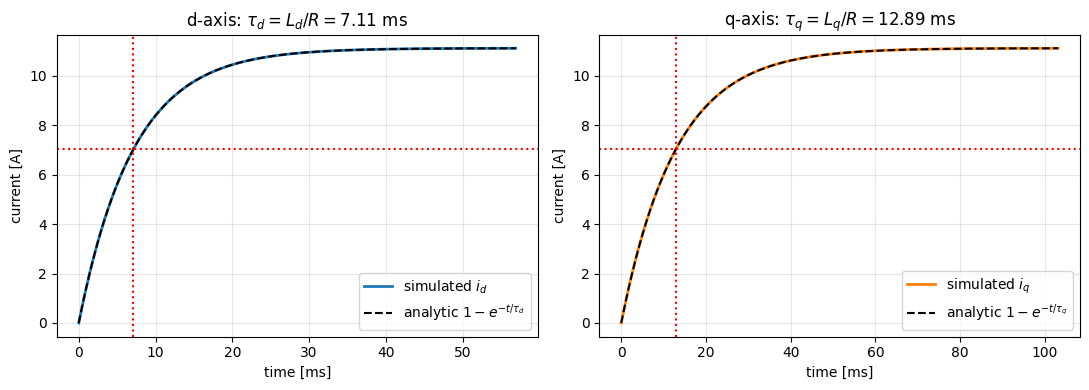

max |sim-analytic|:  d=2.13e-14 A   q=1.78e-14 A


In [5]:
vd = 5.0
tau_d, tau_q = PARAMS["Ld"]/PARAMS["R"], PARAMS["Lq"]/PARAMS["R"]
td, Xd = simulate_pmsm([vd, 0.0], 8*tau_d, locked=True)
tq, Xq = simulate_pmsm([0.0, vd], 8*tau_q, locked=True)
i_ss = vd/PARAMS["R"]
ana_d = i_ss*(1-np.exp(-td/tau_d))
ana_q = i_ss*(1-np.exp(-tq/tau_q))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(td*1e3, Xd[:,0], lw=2, label="simulated $i_d$")
ax[0].plot(td*1e3, ana_d, "k--", label=r"analytic $1-e^{-t/\tau_d}$")
ax[0].axvline(tau_d*1e3, color="r", ls=":"); ax[0].axhline(0.6321*i_ss, color="r", ls=":")
ax[0].set_title(f"d-axis: $\\tau_d=L_d/R={tau_d*1e3:.2f}$ ms")
ax[1].plot(tq*1e3, Xq[:,1], lw=2, color="C1", label="simulated $i_q$")
ax[1].plot(tq*1e3, ana_q, "k--", label=r"analytic $1-e^{-t/\tau_q}$")
ax[1].axvline(tau_q*1e3, color="r", ls=":"); ax[1].axhline(0.6321*i_ss, color="r", ls=":")
ax[1].set_title(f"q-axis: $\\tau_q=L_q/R={tau_q*1e3:.2f}$ ms")
for a in ax:
    a.set_xlabel("time [ms]"); a.set_ylabel("current [A]"); a.grid(alpha=.3); a.legend()
fig.tight_layout(); plt.show()

err_d = float(np.max(np.abs(Xd[:,0]-ana_d)))
err_q = float(np.max(np.abs(Xq[:,1]-ana_q)))
print(f"max |sim-analytic|:  d={err_d:.2e} A   q={err_q:.2e} A")
assert err_d < 1e-3 and err_q < 1e-3

**Figure 1.** Rotor-locked step responses sit on the analytic RL curves;
the red guides mark $t=\tau$ and the $63.2\%$ level. The q-axis is slower because
$L_q>L_d$ — the same saliency that buys reluctance torque costs current-loop
bandwidth, a tension Part 2's controller must balance. Max deviation from the
closed form is $<10^{-3}$ A.

## 5 · Validation II — torque, saliency and the power balance

Two checks here. First, the **torque map** $T_e(i_d, i_q)$ from Eq. (3): the
contours should tilt with $i_d$, and at fixed $i_q$ a negative $i_d$ should raise
torque above the magnet-only value $\tfrac{3}{2}p\lambda_m i_q$ — that gap is the
reluctance torque.

Second, a conservation check the simulator must satisfy at every instant — the
**instantaneous power balance**

$$
\underbrace{\tfrac{3}{2}(v_d i_d + v_q i_q)}_{P_\mathrm{elec}}
= \underbrace{\tfrac{3}{2}R(i_d^2+i_q^2)}_{P_\mathrm{cu}}
+ \underbrace{\tfrac{3}{2}\tfrac{d}{dt}\!\big(\tfrac12 L_d i_d^2+\tfrac12 L_q i_q^2\big)}_{dW_\mathrm{mag}/dt}
+ \underbrace{T_e\,\omega_m}_{P_\mathrm{mech}}.\tag{5}
$$

If the model is wired correctly the residual is numerical noise.

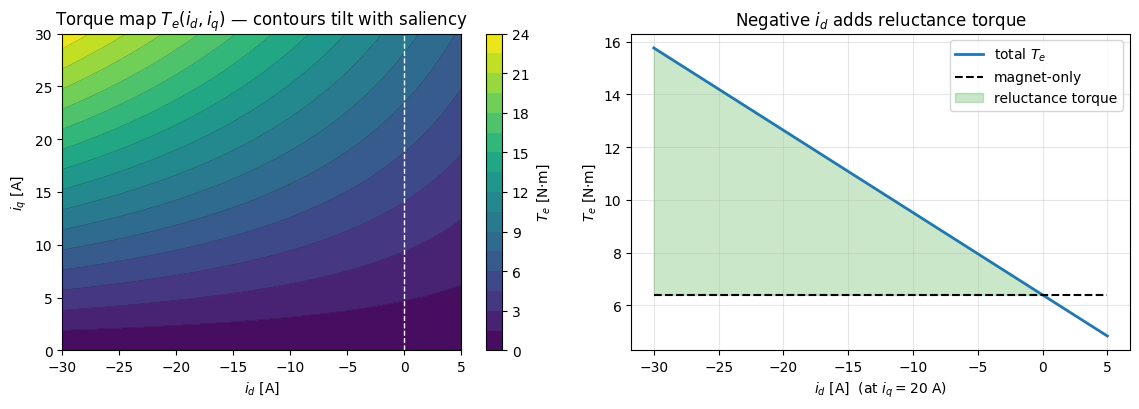

In [6]:
# --- torque map ---
idg = np.linspace(-30, 5, 120); iqg = np.linspace(0, 30, 120)
ID, IQ = np.meshgrid(idg, iqg)
TE = 1.5*PARAMS["p"]*(PARAMS["lam"]*IQ + (PARAMS["Ld"]-PARAMS["Lq"])*ID*IQ)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
cf = ax[0].contourf(ID, IQ, TE, levels=18, cmap="viridis")
ax[0].contour(ID, IQ, TE, levels=18, colors="k", linewidths=.3, alpha=.4)
fig.colorbar(cf, ax=ax[0], label="$T_e$ [N·m]")
ax[0].axvline(0, color="w", ls="--", lw=1)
ax[0].set_xlabel("$i_d$ [A]"); ax[0].set_ylabel("$i_q$ [A]")
ax[0].set_title("Torque map $T_e(i_d,i_q)$ — contours tilt with saliency")

iq_line = 20.0
id_line = np.linspace(-30, 5, 200)
te_tot = 1.5*PARAMS["p"]*(PARAMS["lam"]*iq_line + (PARAMS["Ld"]-PARAMS["Lq"])*id_line*iq_line)
te_mag = 1.5*PARAMS["p"]*PARAMS["lam"]*iq_line*np.ones_like(id_line)
ax[1].plot(id_line, te_tot, lw=2, label="total $T_e$")
ax[1].plot(id_line, te_mag, "k--", label="magnet-only")
ax[1].fill_between(id_line, te_mag, te_tot, where=(te_tot>te_mag), alpha=.25, color="C2",
                   label="reluctance torque")
ax[1].set_xlabel("$i_d$ [A]  (at $i_q=20$ A)"); ax[1].set_ylabel("$T_e$ [N·m]")
ax[1].set_title("Negative $i_d$ adds reluctance torque"); ax[1].grid(alpha=.3); ax[1].legend()
fig.tight_layout(); plt.show()

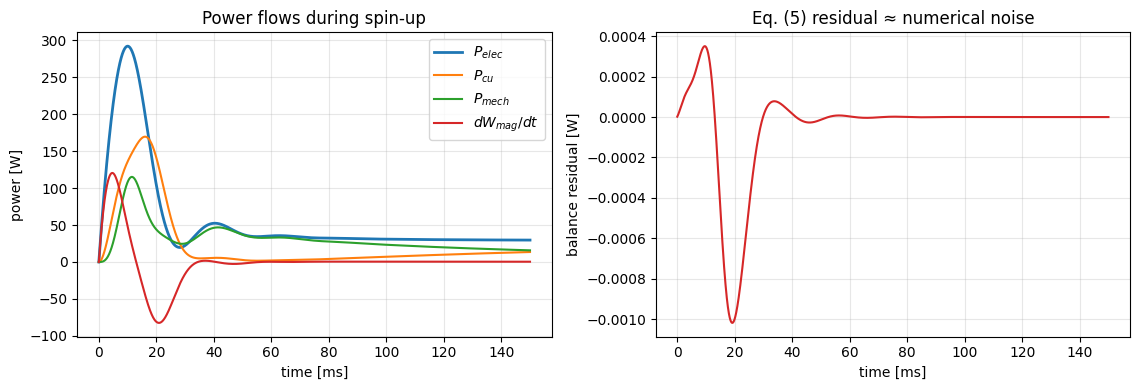

max relative power-balance residual (interior): 3.49e-06


In [7]:
# --- power balance over a spinning trajectory ---
v_drive = [-3.0, 14.0]                      # negative v_d exercises saliency; stable regime
t, X = simulate_pmsm(v_drive, 0.15, T_load=0.0)
i_d, i_q, w_m = X[:,0], X[:,1], X[:,2]
P = PARAMS
di_d = np.gradient(i_d, t); di_q = np.gradient(i_q, t)
P_elec = 1.5*(v_drive[0]*i_d + v_drive[1]*i_q)
P_cu   = 1.5*P["R"]*(i_d**2 + i_q**2)
dWmag  = 1.5*(P["Ld"]*i_d*di_d + P["Lq"]*i_q*di_q)
Te     = 1.5*P["p"]*(P["lam"]*i_q + (P["Ld"]-P["Lq"])*i_d*i_q)
P_mech = Te*w_m
resid  = P_elec - (P_cu + dWmag + P_mech)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ax[0].plot(t*1e3, P_elec, lw=2, label="$P_{elec}$")
ax[0].plot(t*1e3, P_cu, label="$P_{cu}$")
ax[0].plot(t*1e3, P_mech, label="$P_{mech}$")
ax[0].plot(t*1e3, dWmag, label="$dW_{mag}/dt$")
ax[0].set_xlabel("time [ms]"); ax[0].set_ylabel("power [W]"); ax[0].grid(alpha=.3); ax[0].legend()
ax[0].set_title("Power flows during spin-up")
# ignore the gradient end-points (one-sided diff)
ax[1].plot(t[2:-2]*1e3, resid[2:-2], color="C3")
ax[1].set_xlabel("time [ms]"); ax[1].set_ylabel("balance residual [W]")
ax[1].set_title("Eq. (5) residual ≈ numerical noise"); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

rel = float(np.max(np.abs(resid[2:-2])) / np.max(np.abs(P_elec)))
print(f"max relative power-balance residual (interior): {rel:.2e}")
assert rel < 5e-3

**Figure 2.** *Left:* the torque map's contours tilt because of the
$(L_d-L_q)i_d i_q$ term; *right:* at $i_q=20$ A, pushing $i_d$ negative lifts
torque above the magnet-only line — free torque from geometry. **Figure 3.** The
four power flows of Eq. (5) sum to the electrical input; the residual is
$\sim\!10^{-3}$ relative (finite-difference on $dW_\mathrm{mag}/dt$ dominates it,
not the model). Conservation holding to numerical precision is the strongest
evidence the block is wired correctly.

## 6 · Reading an open-loop spin-up

Now the full machine, unlocked. We apply a constant $v_q = 15$ V — deliberately
in the *open-loop-stable* regime (§7 shows the machine becomes unstable above
$\sim$19 V) — at no load, and watch it accelerate. Every feature of the trace
follows from the equations:

- **current spike then collapse** — at standstill there is no back-EMF, so $v_q$
  drives a large $i_q$ (large torque); as speed builds, the $\omega_e\lambda_m$
  term in Eq. (2) cancels $v_q$ and $i_q\to 0$;
- **steady speed** at $\omega_m \approx v_q/(p\,\lambda_m)$, where back-EMF
  balances the applied voltage and $T_e$ falls to nearly zero (no load);
- **$i_d$ stays near zero** — there is no d-axis command yet (Part 2); the small
  excursion is pure $\omega_e L_q i_q$ cross-coupling.

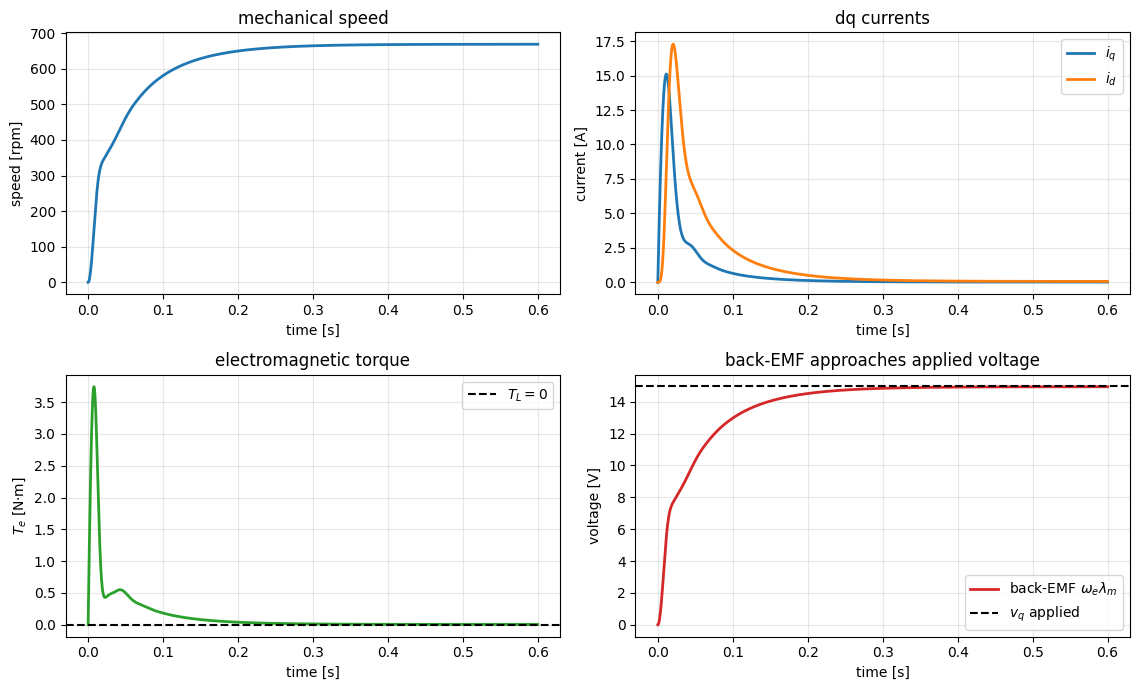

steady speed ~ 669 rpm (predicted v_q/(p*lam) = 672 rpm)
i_q(end)=0.018 A   i_d(end)=0.065 A   back-EMF(end)=14.93 V (v_q=15.0)


In [8]:
v_q = 15.0          # open-loop-stable regime (below ~19 V; see §7)
t, X = simulate_pmsm([0.0, v_q], 0.6, T_load=0.0, n=3000)
i_d, i_q, w_m = X[:,0], X[:,1], X[:,2]
Te = electromagnetic_torque(i_d, i_q, **PARAMS)
rpm = w_m*60/(2*np.pi)
back_emf = PARAMS["p"]*w_m*PARAMS["lam"]

fig, ax = plt.subplots(2, 2, figsize=(11.5, 7))
ax[0,0].plot(t, rpm, lw=2); ax[0,0].set_title("mechanical speed")
ax[0,0].set_ylabel("speed [rpm]")
ax[0,1].plot(t, i_q, lw=2, label="$i_q$"); ax[0,1].plot(t, i_d, lw=2, label="$i_d$")
ax[0,1].set_title("dq currents"); ax[0,1].set_ylabel("current [A]"); ax[0,1].legend()
ax[1,0].plot(t, Te, lw=2, color="C2")
ax[1,0].axhline(0.0, color="k", ls="--", label="$T_L=0$")
ax[1,0].set_title("electromagnetic torque"); ax[1,0].set_ylabel("$T_e$ [N·m]"); ax[1,0].legend()
ax[1,1].plot(t, back_emf, lw=2, color="C3", label=r"back-EMF $\omega_e\lambda_m$")
ax[1,1].axhline(v_q, color="k", ls="--", label="$v_q$ applied")
ax[1,1].set_title("back-EMF approaches applied voltage"); ax[1,1].set_ylabel("voltage [V]"); ax[1,1].legend()
for a in ax.ravel(): a.set_xlabel("time [s]"); a.grid(alpha=.3)
fig.tight_layout(); plt.show()

speed_pred = v_q / (PARAMS["p"] * PARAMS["lam"]) * 60 / (2*np.pi)
print(f"steady speed ~ {rpm[-1]:.0f} rpm (predicted v_q/(p*lam) = {speed_pred:.0f} rpm)")
print(f"i_q(end)={i_q[-1]:.3f} A   i_d(end)={i_d[-1]:.3f} A   back-EMF(end)={back_emf[-1]:.2f} V (v_q={v_q})")
assert abs(rpm[-1] - speed_pred)/speed_pred < 0.05      # back-EMF speed law
assert abs(i_q[-1]) < 0.5                                # i_q collapses at no load
assert abs(back_emf[-1] - v_q) < 1.0                     # back-EMF meets applied v

**Figure 4.** No-load open-loop spin-up at $v_q=15$ V. Torque and $i_q$
spike then decay to ~zero as the back-EMF (bottom-right) climbs to meet the
applied voltage; the machine settles at $\approx\!669$ rpm, exactly
$v_q/(p\lambda_m)$. This clean behaviour holds *only* in the open-loop-stable
regime — §7 shows what lies beyond it, and why field-oriented control is not
optional.

## 7 · Failure modes

Models earn trust by showing where they break. Each case below is a real drive
pathology this model reproduces.

1. **Open-loop instability.** Driven by voltage alone, the IPMSM follows the
   back-EMF speed law $\omega_m\approx v_q/(p\lambda_m)$ only up to $\sim$19 V;
   above that the equilibrium bifurcates and the machine collapses into a
   high-current, low-speed branch (tens of amps, a fraction of the expected
   speed). Open-loop voltage drive is *not* globally stable — this is the single
   clearest motivation for the closed-loop current control of Part 2.
2. **No load regulation.** Even on the stable branch, applying load sags the
   speed badly — there is no integral action to hold a setpoint. A speed loop
   (Part 2) fixes this.
3. **Saliency sign error.** Swapping $L_d\leftrightarrow L_q$ flips the
   reluctance term, so negative $i_d$ would *cost* torque — a common modelling
   bug worth being able to spot from the inverted torque curve.

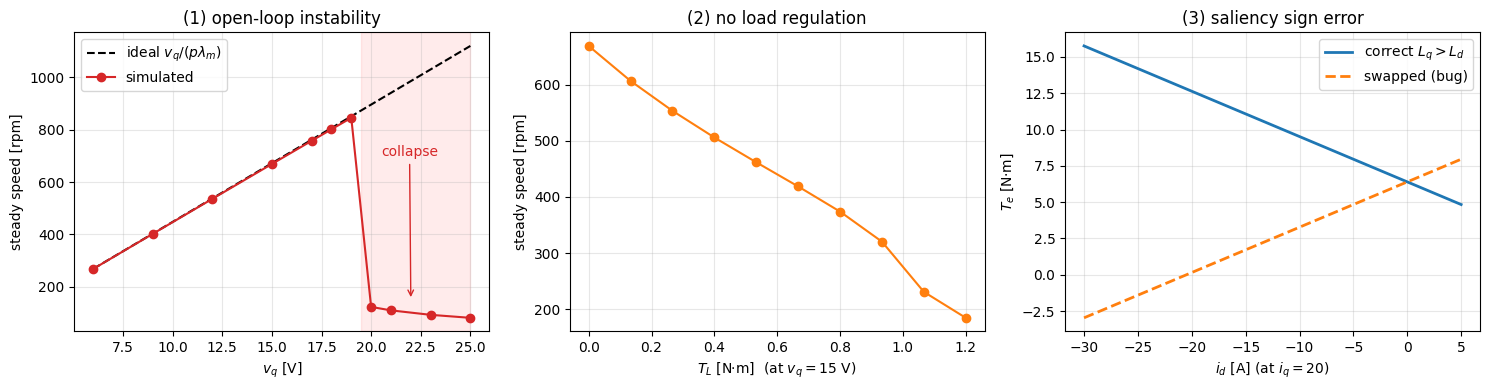

stable up to v_q=19 V; speed sags 669 -> 185 rpm under 1.2 N·m load


In [9]:
# (1) open-loop instability: no-load steady speed vs applied v_q
vqs = np.array([6, 9, 12, 15, 17, 18, 19, 20, 21, 23, 25], dtype=float)
rpm_vq = np.array([simulate_pmsm([0.0, float(vq)], 0.9, T_load=0.0, n=1800)[1][-1, 2]
                   for vq in vqs]) * 60/(2*np.pi)
rpm_ideal = vqs/(PARAMS["p"]*PARAMS["lam"]) * 60/(2*np.pi)   # back-EMF speed law

# (2) poor load regulation on the stable branch (v_q = 15 V)
loads = np.linspace(0.0, 1.2, 10)
rpm_TL = np.array([simulate_pmsm([0.0, 15.0], 0.9, T_load=float(TL), n=1800)[1][-1, 2]
                   for TL in loads]) * 60/(2*np.pi)

# (3) saliency sign error
P_swap = dict(PARAMS); P_swap["Ld"], P_swap["Lq"] = PARAMS["Lq"], PARAMS["Ld"]
te_ok  = 1.5*PARAMS["p"]*(PARAMS["lam"]*iq_line + (PARAMS["Ld"]-PARAMS["Lq"])*id_line*iq_line)
te_bad = 1.5*P_swap["p"]*(P_swap["lam"]*iq_line + (P_swap["Ld"]-P_swap["Lq"])*id_line*iq_line)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(vqs, rpm_ideal, "k--", label=r"ideal $v_q/(p\lambda_m)$")
ax[0].plot(vqs, rpm_vq, "o-", color="C3", label="simulated")
ax[0].axvspan(19.5, 25, color="red", alpha=.08)
ax[0].annotate("collapse", xy=(22, 150), xytext=(20.5, 700),
               arrowprops=dict(arrowstyle="->", color="C3"), color="C3")
ax[0].set_title("(1) open-loop instability"); ax[0].set_xlabel("$v_q$ [V]")
ax[0].set_ylabel("steady speed [rpm]"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].plot(loads, rpm_TL, "o-", color="C1"); ax[1].set_title("(2) no load regulation")
ax[1].set_xlabel("$T_L$ [N·m]  (at $v_q=15$ V)"); ax[1].set_ylabel("steady speed [rpm]"); ax[1].grid(alpha=.3)
ax[2].plot(id_line, te_ok, lw=2, label="correct $L_q>L_d$")
ax[2].plot(id_line, te_bad, lw=2, ls="--", label="swapped (bug)")
ax[2].set_title("(3) saliency sign error"); ax[2].set_xlabel("$i_d$ [A] (at $i_q=20$)")
ax[2].set_ylabel("$T_e$ [N·m]"); ax[2].grid(alpha=.3); ax[2].legend()
fig.tight_layout(); plt.show()

print(f"stable up to v_q={vqs[rpm_vq>0.5*rpm_ideal].max():.0f} V; "
      f"speed sags {rpm_TL[0]:.0f} -> {rpm_TL[-1]:.0f} rpm under 1.2 N·m load")

**Figure 5.** (1) no-load steady speed tracks the ideal $v_q/(p\lambda_m)$
line until $\sim$19 V, then collapses into the high-current branch (shaded) —
the open-loop instability; (2) on the stable branch, speed sags from $\sim$669 to
$\sim$185 rpm as load grows to 1.2 N·m, with no restoring action; (3) the
saliency-swap bug inverts the reluctance slope. Cases (1) and (2) are precisely
what field-oriented control exists to cure — the subject of Part 2.

## Exercises

- **(Easy)** Change $\lambda_m$ by $\pm10\%$ and re-run the spin-up. How does the
  speed ceiling move? Explain via the back-EMF relation.
- **(Medium)** Add a $q$-axis current *measurement* output port and a simple
  proportional voltage law $v_q = K(i_q^\star - i_q)$. You've built the seed of
  Part 2's current loop — what $K$ makes the closed-loop bandwidth $\sim$1 kHz?
- **(Hard)** Replace the constant $L_d, L_q$ with `LookupTable2d` saturation maps
  $L_d(i_d,i_q)$, $L_q(i_d,i_q)$ and re-validate the power balance — does Eq. (5)
  still hold once inductance varies with current? (Hint: $W_\mathrm{mag}$ is no
  longer quadratic.)
- **(Open)** The averaged inverter hides switching ripple. Sketch how you would
  add a PWM carrier and what solver setting (see `ode_solver_method`) you'd need
  to resolve it without the step size collapsing.

## Next steps

**Part 2 — Field-oriented control** closes the loop: Clarke/Park transforms turn
the three phase currents into the dq pair this model speaks, two PI regulators
drive $i_d, i_q$ to references, a speed loop sits on top, and we run the machine
to a commanded torque/speed with the voltage budget actively managed.

## References

1. P. Krause, O. Wasynczuk, S. Sudhoff, S. Pekarek, *Analysis of Electric
   Machinery and Drive Systems*, 3rd ed., Wiley-IEEE, 2013 — dq machine model,
   Eqs. (1)–(4).
2. N. Mohan, *Advanced Electric Drives: Analysis, Control, and Modeling Using
   MATLAB/Simulink*, Wiley, 2014 — IPMSM saliency and reluctance torque, Eq. (3).
3. R. H. Park, "Two-reaction theory of synchronous machines," *Trans. AIEE*,
   1929 — the dq transformation.
4. B. Bose, *Modern Power Electronics and AC Drives*, Prentice Hall, 2002 —
   averaged inverter and the $V_\mathrm{dc}/\sqrt3$ voltage limit.